In [1]:
from pathlib import Path
from typing import Tuple, List
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from __future__ import annotations

In [2]:
class Capability:
    def __init__(self, line, parent):
        #print(line)
        _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms   = line.split()
        self.boundsOffset = int(boundsOffset, 16)
        self.boundsLength = int(boundsLength, 16)
        self.boundsVirtBase = int(boundsVirtualBase, 16)
        self.capPerms = int(capPerms, 16)
        self.parent = parent
        parent.child = self

    def capKey(self):
        return (self.boundsVirtBase, self.boundsLength)
    
    def __eq__(self, other):
        return self.boundsOffset == other.boundsOffset and self.boundsLength == other.boundsLength and self.boundsVirtBase == other.boundsVirtBase and self.capPerms == other.capPerms

    def __hash__(self):
        return hash((self.boundsOffset, self.boundsLength, self.boundsVirtBase, self.capPerms))
    
    def __repr__(self):
        return f"Cap virtBase {self.boundsVirtBase} length {self.boundsLength} offset {self.boundsOffset}"

class ReportAccessLog:
    def __init__(self, line, index):
        #44200 Prefetcher logReportAccess level 1 addr 00000000c0007648 pcHash c0000260 hitMiss 1 boundsOffset 0000000000000008 boundsLength 0000000000002f30 boundsVirtBase 00000000c0007640 capPerms 0000000000001111000111111010111

        #print(line.split())
        clock_time,_, _, _, level, _, addr, _, pcHash, _, isMiss, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms, _, op   = line.split()
        self.clock_time = int(clock_time)/10
        self.level = int(level)
        self.addr = int(addr, 16)
        self.pcHash = int(pcHash, 16)
        self.isMiss = int(isMiss)
        self.op = op
        self.cap = Capability("boundsOffset"+line.partition("op")[0].partition("boundsOffset")[2], self)

        self.index = index
    
class ReportDataArrivalCap:
    def __init__(self, line, parent):
        pre, _, cap = line.partition("boundsOffset")
        _, _, _, _, index, _, tag, _, addr = pre.split()
        self.index = int(index)
        self.tag = bool(int(tag))
        self.addr = int(addr, 16)
        if self.tag:
            self.cap = Capability("boundsOffset"+cap, parent)
        self.parent = parent
        parent.child = self

class ReportDataArrival:
    def __init__(self, line, index):
        clock_time,_, _, _, level, _, requestAddr, _, pcHash, _, wasMiss, _, wasPrefetch, _, boundsOffset, _, boundsLength, _, boundsVirtualBase, _, capPerms, _, op  = line.split()
        self.clock_time = int(clock_time)/10
        self.level = int(level)
        self.requestAddr = int(requestAddr, 16)
        self.pcHash = int(pcHash, 16)
        self.wasMiss = int(wasMiss)
        self.wasPrefetch = int(wasPrefetch)

        #print(line)
        self.requestCap = Capability("boundsOffset"+line.partition("op")[0].partition("boundsOffset")[2], self)
        self.capabilites: List[ReportDataArrivalCap] = []

        self.index = index

    def add_capability(self, line, parent_data_arrivals):
        capability = ReportDataArrivalCap(line, self)
        if capability.tag:
            self.capabilites.append(capability)
            parent_data_arrivals[capability.cap.capKey()] = capability.cap 

        return capability




def parse_log(input_file) -> Tuple[List[ReportAccessLog], List[ReportDataArrival], List[ReportAccessLog]]:
    recent_misses = set()
    parent_access = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    parent_data_arrivals = {} #(cap_virtual_base, cap_size, most recent ReportAccessLog)
    accesses = []
    data_arrivals = []
    access_misses = []

    access_index = 0
    data_arrival_index = 0
    

    with open(input_file, "r") as fp:
        while True:
            line = fp.readline()
            if not line:
                break

            if "logReportAccess" in line:
                reportAccess = ReportAccessLog(line, access_index)
                access_index += 1

                if reportAccess.isMiss:
                    recent_misses.add(reportAccess.addr)
                    access_misses.append(reportAccess)
                elif reportAccess.addr in recent_misses:
                    #Skip first hit access after miss
                    recent_misses.remove(reportAccess.addr)
                    continue

                accesses.append(reportAccess)
                parent_access[reportAccess.cap.capKey()] = reportAccess.cap

                if reportAccess.cap.capKey() in parent_data_arrivals:
                    parent = parent_data_arrivals[reportAccess.cap.capKey()]
                    reportAccess.parent = parent
                    parent.child = reportAccess
                    #parent.child = reportAccess
                    #print("found parent")

                # if reportAccess.cap.boundsLength == 40000:
                #         print("40000 arrival")
                #         print(reportAccess.cap.capKey())
                #print(reportAccess.cap.boundsLength)
            
            elif "logReportDataArrival" in line:
                data_arrival = ReportDataArrival(line, data_arrival_index)
                data_arrival_index += 1 

                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrival.add_capability(fp.readline(), parent_data_arrivals)
                data_arrivals.append(data_arrival)

                if data_arrival.requestCap.capKey() in parent_access:
                    # if data_arrival.requestCap.boundsLength == 40000:
                    #     print("40000 arrival in arrival")
                    parent = parent_access[data_arrival.requestCap.capKey()]
                    data_arrival.parent = parent
                    parent.child = data_arrival
                    #parent.child = data_arrival
                    #print("found parent2")

                # if data_arrival.requestCap.boundsLength == 40000:
                #     print(data_arrival.requestCap.capKey())
                    


    print(f"access {len(accesses)} misses {len(access_misses)}")
    return accesses, data_arrivals, access_misses

In [3]:
#input_file = Path("../simulations/adpcm_decode") / "sim_0.0" / "sim_stdout"
input_file = Path("../simulations/patricia") / "sim_0.0" / "sim_stdout"

accesses, data_arrivals, access_misses = parse_log(input_file)

access 1947601 misses 42816


# Core capability summaries

In [4]:
virt_base_to_access = defaultdict(list)
for access in accesses:
    virt_base_to_access[access.cap.boundsVirtBase].append(access)

In [5]:
def find_timely_pc(virt_base_to_access, virt_base, end_time, time_before):
    limited_access = virt_base_to_access[virt_base]
    for access in reversed(limited_access):
        if access.clock_time <= end_time - time_before:
            return access

In [6]:
accesses[1]

In [7]:
pc_miss_parent_offset = defaultdict(int)
pc_miss_parent_and_child_offset = defaultdict(int)
pc_miss_parent_and_child_offset_timeliness = defaultdict(list)


pc_timely = defaultdict(int)
pc_timely_child_offset = defaultdict(int)
access_between = defaultdict(list)
no_timely = 0

for data_arrival in data_arrivals:
    if data_arrival.wasMiss:

        if hasattr(data_arrival.parent.parent, 'parent'):
            parent_arrival = data_arrival.parent.parent.parent.parent.parent.parent
            miss_time = data_arrival.clock_time - parent_arrival.clock_time # time from start of miss request to end

            # pc_miss_parent_offset[parent_arrival.pcHash, parent_arrival.requestCap.boundsOffset] += 1
            # pc_miss_parent_and_child_offset[parent_arrival.pcHash, parent_arrival.requestCap.boundsOffset, data_arrival.requestCap.boundsOffset] += 1
            # pc_miss_parent_and_child_offset_timeliness[parent_arrival.pcHash, parent_arrival.requestCap.boundsOffset, data_arrival.requestCap.boundsOffset].append(data_arrival.clock_time - parent_arrival.clock_time)

            timely_arrival = find_timely_pc(virt_base_to_access, parent_arrival.cap.boundsVirtBase, parent_arrival.clock_time, miss_time)
            if timely_arrival:
                pc_timely[timely_arrival.pcHash, parent_arrival.cap.boundsOffset] += 1
                pc_timely_child_offset[timely_arrival.pcHash, parent_arrival.cap.boundsOffset, data_arrival.requestCap.boundsOffset] += 1
                access_between[timely_arrival.pcHash, parent_arrival.cap.boundsOffset, data_arrival.requestCap.boundsOffset].append(parent_arrival.index - timely_arrival.index)
            else:
                no_timely += 1



In [47]:
no_timely

588

In [56]:
np.median(access_between[(3221233150, 0, 33)])

4213.5

In [58]:
{k:(v, np.median(access_between[k])) for k,v in sort_by_count(pc_timely_child_offset).items()}

{(3221233150, 0, 33): (844, 4213.5),
 (3221233150, 0, 48): (770, 433.0),
 (3221233154, 48, 33): (627, 3.0),
 (3221233154, 64, 33): (617, 3.0),
 (3221233150, 0, 64): (427, 15788.0),
 (3221233126, 0, 0): (368, 2087.5),
 (3221233126, 64, 33): (346, 48.0),
 (3221233126, 48, 33): (311, 218.0),
 (3221233200, 0, 0): (302, 3.0),
 (3221233146, 64, 33): (295, 4.0),
 (3221233150, 0, 16): (258, 4196.5),
 (3221233150, 0, 0): (221, 20038.0),
 (3221233126, 48, 48): (198, 216.0),
 (3221233146, 48, 33): (181, 4.0),
 (3221233126, 64, 64): (159, 11.0),
 (3221233154, 48, 48): (156, 4.0),
 (3221233154, 64, 64): (143, 3.0),
 (3221233126, 48, 64): (132, 112.5),
 (3221234324, 0, 0): (126, 1197.5),
 (3221233126, 64, 48): (124, 8.0),
 (3221233146, 64, 64): (118, 5.0),
 (3221233196, 0, 33): (114, 10377.0),
 (3221233134, 0, 0): (111, 5.0),
 (3221233134, 64, 33): (109, 5.0),
 (3221233154, 48, 64): (107, 4.0),
 (3221236376, 3221617648, 0): (96, 7.0),
 (3221236376, 3221617696, 0): (89, 6.0),
 (3221233154, 0, 0): (85

In [51]:
sort_by_count(pc_timely_child_offset)

{(3221233150, 0, 33): 844,
 (3221233150, 0, 48): 770,
 (3221233154, 48, 33): 627,
 (3221233154, 64, 33): 617,
 (3221233150, 0, 64): 427,
 (3221233126, 0, 0): 368,
 (3221233126, 64, 33): 346,
 (3221233126, 48, 33): 311,
 (3221233200, 0, 0): 302,
 (3221233146, 64, 33): 295,
 (3221233150, 0, 16): 258,
 (3221233150, 0, 0): 221,
 (3221233126, 48, 48): 198,
 (3221233146, 48, 33): 181,
 (3221233126, 64, 64): 159,
 (3221233154, 48, 48): 156,
 (3221233154, 64, 64): 143,
 (3221233126, 48, 64): 132,
 (3221234324, 0, 0): 126,
 (3221233126, 64, 48): 124,
 (3221233146, 64, 64): 118,
 (3221233196, 0, 33): 114,
 (3221233134, 0, 0): 111,
 (3221233134, 64, 33): 109,
 (3221233154, 48, 64): 107,
 (3221236376, 3221617648, 0): 96,
 (3221236376, 3221617696, 0): 89,
 (3221233154, 0, 0): 85,
 (3221233134, 64, 64): 85,
 (3221236376, 3221617920, 0): 84,
 (3221235598, 130864, 33): 77,
 (3221237310, 64, 24): 77,
 (3221235938, 3221617664, 432): 70,
 (3221233192, 0, 0): 70,
 (3221235710, 64, 240): 68,
 (3221234324, 

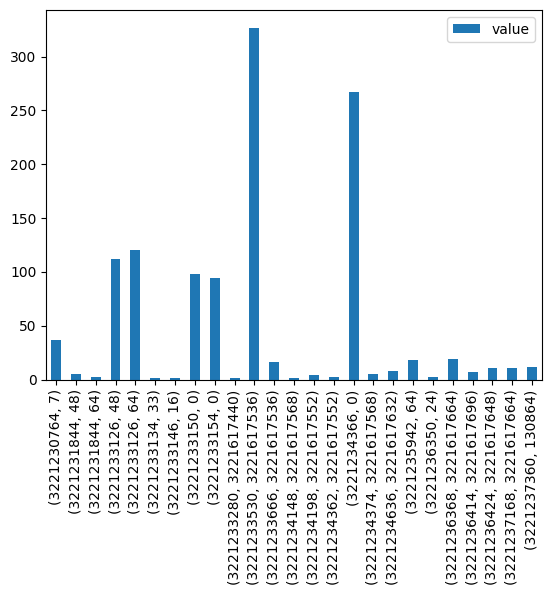

In [54]:
plot_count(pc_miss_parent)

In [55]:
pc_miss_parent_and_child_offset

defaultdict(int,
            {(3221233280, 3221617440, 0): 1,
             (3221234148, 3221617568, 4): 1,
             (3221233530, 3221617536, 50): 2,
             (3221234366, 0, 68): 1,
             (3221234366, 0, 132): 1,
             (3221233530, 3221617536, 196): 1,
             (3221233530, 3221617536, 260): 1,
             (3221234366, 0, 324): 1,
             (3221233530, 3221617536, 388): 1,
             (3221234366, 0, 452): 1,
             (3221233530, 3221617536, 516): 1,
             (3221233530, 3221617536, 580): 1,
             (3221234366, 0, 644): 1,
             (3221233530, 3221617536, 708): 1,
             (3221233530, 3221617536, 772): 1,
             (3221233530, 3221617536, 836): 1,
             (3221233530, 3221617536, 900): 1,
             (3221233530, 3221617536, 964): 1,
             (3221233530, 3221617536, 1028): 1,
             (3221233530, 3221617536, 1092): 1,
             (3221234366, 0, 1156): 1,
             (3221233530, 3221617536, 1220): 1,
     

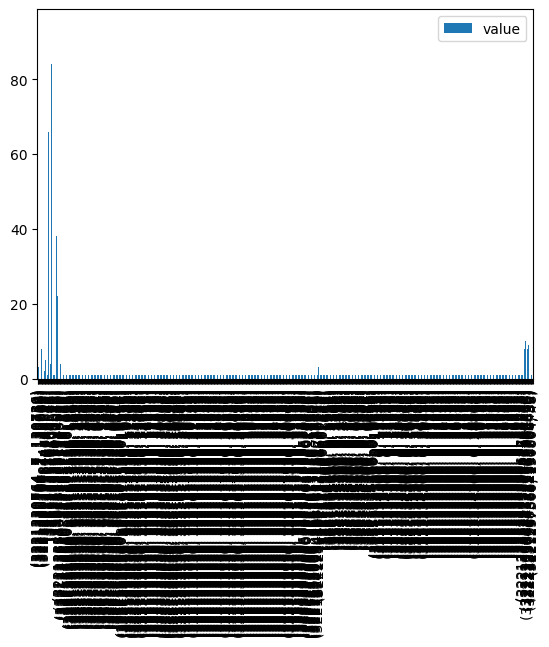

In [56]:
plot_count(pc_miss_parent_and_child_offset)

In [59]:
sort_by_count({k: (len(v), np.median(np.array(v))) for k,v in pc_miss_parent_and_child_offset_timeliness.items()})

{(3221233154, 0, 0): (94, 15.0),
 (3221233126, 64, 33): (84, 16.0),
 (3221233126, 48, 33): (66, 16.0),
 (3221233150, 0, 33): (38, 10.0),
 (3221233126, 48, 48): (30, 20.5),
 (3221233126, 64, 64): (27, 21.0),
 (3221233150, 0, 48): (22, 16.5),
 (3221233150, 0, 64): (19, 19.0),
 (3221236424, 3221617648, 0): (11, 16.0),
 (3221233126, 48, 64): (10, 28.0),
 (3221237360, 130864, 33): (10, 19.0),
 (3221233150, 0, 0): (10, 17.0),
 (3221237168, 3221617664, 0): (10, 12.0),
 (3221235942, 64, 240): (10, 5.0),
 (3221233150, 0, 16): (9, 10.0),
 (3221236368, 3221617664, 432): (9, 5.0),
 (3221230764, 7, 130880): (8, 828051.0),
 (3221234636, 3221617632, 0): (8, 16.0),
 (3221235942, 64, 24): (8, 13.0),
 (3221236368, 3221617664, 64): (8, 8.0),
 (3221230764, 7, 130944): (7, 903450.0),
 (3221236414, 3221617696, 0): (7, 16.0),
 (3221230764, 7, 130752): (6, 669211.5),
 (3221233126, 64, 48): (5, 26.0),
 (3221233126, 48, 0): (5, 19.0),
 (3221231844, 48, 33): (5, 17.0),
 (3221234374, 3221617568, 0): (5, 16.0),
 (

In [58]:
plot_count({k: np.median(np.array(v)) for k,v in pc_miss_parent_and_child_offset_timeliness.items()})

SyntaxError: closing parenthesis '}' does not match opening parenthesis '(' (419082463.py, line 1)

In [ ]:
pc_miss_parent_and_child_offset_timeliness

{(3221230764, 7, 130720): [11164890],
 (3221230764, 7, 131008): [5390040, 9034540],
 (3221230764, 7, 130768): [2417900, 5119200, 9177930],
 (3221230764, 7, 130904): [2221610, 4433670],
 (3221230764, 7, 130752): [1958930,
  2856600,
  4666950,
  8717280,
  9623400,
  11612990],
 (3221230764, 7, 130944): [1710280,
  4421160,
  8466460,
  9034500,
  9152060,
  10482940,
  11806860],
 (3221230764, 7, 130736): [1509350, 5592310, 12044750],
 (3221230764, 7, 130960): [1302900],
 (3221230764, 7, 130880): [1302770,
  1486000,
  4675570,
  7154280,
  9406740,
  10955960,
  11619420,
  12248500],
 (3221230764, 7, 130816): [1067200, 1515630, 3091700, 10726900],
 (3221233280, 3221617440, 0): [16070],
 (3221234148, 3221617568, 4): [9050],
 (3221233530, 3221617536, 50): [4510, 230],
 (3221234366, 0, 15748): [2410],
 (3221233530, 3221617536, 18116): [2380],
 (3221234366, 0, 20932): [2370],
 (3221234366, 0, 324): [2350],
 (3221233530, 3221617536, 6148): [2350],
 (3221234366, 0, 12548): [2350],
 (322123

# Old

In [16]:
def sort_by_count(d):
    return dict(sorted(d.items(), key=lambda item: item[1], reverse=True))

In [17]:
def set_dict_to_count(set_dict):
    return {k: len(v) for k,v in set_dict.items()}
def plot_count(count_dict: dict, xlabel="", ylabel=""):
    df = pd.DataFrame(data = {"key": count_dict.keys(), "value": count_dict.values()})
    df = df.sort_values("key")
    df.plot(kind="bar", x="key", y="value", xlabel=xlabel, ylabel=ylabel)

In [9]:
class CapabilityAnalysis:
    def __init__(self, virtBase, length):
        self.virtBase = virtBase
        self.length = length
        self.internalOffsets = defaultdict(int)
        self.externalCapOffset = defaultdict(set)

    def addOffset(self, cap, offset):
        if cap.length == self.length and cap.virtBase == self.virtBase:
            self.internalOffsets[offset] += 1
        else:
            self.externalCapOffset[offset].add(cap)

    def __repr__(self):
        return f"CapAnalysis virtBase {self.virtBase} length {self.length} interalOffset {self.internalOffsets} externalOffset {self.externalCapOffset}"

In [ ]:
cap_analysis_map = {}
cap_to_recent_parent = {}

all_caps = set()
for data_arrival in data_arrivals:
    
    if data_arrival.requestCap.capKey() not in cap_analysis_map:
        cap_analysis_map[data_arrival.requestCap.capKey()] = CapabilityAnalysis(data_arrival.requestCap.boundsVirtBase, data_arrival.requestCap.boundsLength)


    if data_arrival.requestCap.capKey() in cap_to_recent_parent.keys():
        parentCap, offset = cap_to_recent_parent[data_arrival.requestCap.capKey()]
        parentCap.addOffset(cap_analysis_map[data_arrival.requestCap.capKey()], data_arrival.requestCap.boundsOffset)
        # print("here???")
    #else:
        #print(data_arrival.requestCap.capKey())
    
    # if data_arrival.requestCap.capKey() in all_caps:
    #     print("Confused2")

    for i, cap in enumerate(data_arrival.capabilites):
        if cap.cap.capKey() not in cap_analysis_map:
            cap_analysis_map[cap.cap.capKey()] = CapabilityAnalysis(cap.cap.boundsVirtBase, cap.cap.boundsLength)
        cap_to_recent_parent[cap.cap.capKey()] = (cap_analysis_map[data_arrival.requestCap.boundsVirtBase, data_arrival.requestCap.boundsLength], data_arrival.requestCap.boundsOffset+i*4)
        # all_caps.add(cap.cap.capKey())

In [28]:
cap_to_recent_parent

{(3221251344,
  16): (CapAnalysis virtBase 0 length 18446744073709551615 interalOffset defaultdict(<class 'int'>, {}) externalOffset defaultdict(<class 'set'>, {3221310288: {CapAnalysis virtBase 3221251344 length 16 interalOffset defaultdict(<class 'int'>, {}) externalOffset defaultdict(<class 'set'>, {})}, 3221310292: {CapAnalysis virtBase 3221251328 length 16 interalOffset defaultdict(<class 'int'>, {}) externalOffset defaultdict(<class 'set'>, {})}, 3221310396: {CapAnalysis virtBase 3221309629 length 23 interalOffset defaultdict(<class 'int'>, {}) externalOffset defaultdict(<class 'set'>, {})}, 3221310524: {CapAnalysis virtBase 3221311020 length 4 interalOffset defaultdict(<class 'int'>, {}) externalOffset defaultdict(<class 'set'>, {})}, 3221310520: {CapAnalysis virtBase 3221311488 length 16 interalOffset defaultdict(<class 'int'>, {}) externalOffset defaultdict(<class 'set'>, {0: {CapAnalysis virtBase 3221311744 length 160000 interalOffset defaultdict(<class 'int'>, {32: 23, 36: 2

In [29]:
import csv
with open('edges.csv', 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile, delimiter=' ',
                            quotechar='"', quoting=csv.QUOTE_MINIMAL)
    csvwriter.writerow(["Source", "Target", "Label"])
    for v in cap_analysis_map.values():
        for offset, count in v.internalOffsets.items():
            csvwriter.writerow([(v.virtBase, v.length), (v.virtBase, v.length), f"Offset: {offset}, count {count}"])

        for offset, caps in v.externalCapOffset.items():
            for cap in caps:
                csvwriter.writerow([(v.virtBase, v.length), (cap.virtBase, cap.length), f"Offset: {offset}"])
    

# Offset analysis

In [9]:
cap_prev_offset = defaultdict(int)
pc_diff_offset = defaultdict(int)
cap_diff_offset = defaultdict(int)

pc_num_offsets = defaultdict(set)
pc_offsets = defaultdict(int)
caps_offset = defaultdict(int)
caps_num_offsets = defaultdict(set)
pc_cap_num_offsets = defaultdict(set)
pcs = set()

for i, data_arrival in enumerate(data_arrivals):
    pc_num_offsets[data_arrival.pcHash].add(data_arrival.requestCap.boundsOffset)
    pc_offsets[data_arrival.pcHash, data_arrival.requestCap.boundsOffset] += 1
    caps_offset[data_arrival.requestCap.boundsVirtBase, data_arrival.requestCap.boundsOffset] += 1
    caps_num_offsets[data_arrival.requestCap.boundsVirtBase].add(data_arrival.requestCap.boundsOffset)
    pcs.add(data_arrival.pcHash)
    pc_cap_num_offsets[data_arrival.pcHash, data_arrival.requestCap.boundsVirtBase].add(data_arrival.requestCap.boundsOffset)

    pc_diff_offset[data_arrival.pcHash, data_arrival.requestCap.boundsOffset - cap_prev_offset[data_arrival.requestCap.boundsVirtBase]] += 1
    cap_diff_offset[data_arrival.requestCap.boundsVirtBase, data_arrival.requestCap.boundsOffset - cap_prev_offset[data_arrival.requestCap.boundsVirtBase]] += 1
    cap_prev_offset[data_arrival.requestCap.boundsVirtBase] = data_arrival.requestCap.boundsOffset

    chain = [data_arrival.requestCap.boundsOffset]


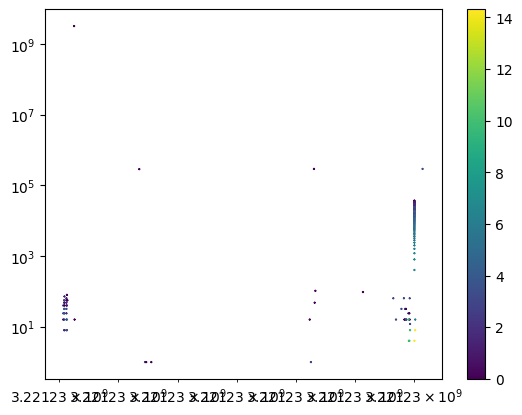

In [10]:
sc = plt.scatter(*zip(*pc_diff_offset.keys()), c=np.log(list(pc_diff_offset.values())), marker='x', s = 0.5)
plt.yscale('log')
plt.xscale('log')
plt.colorbar(sc)

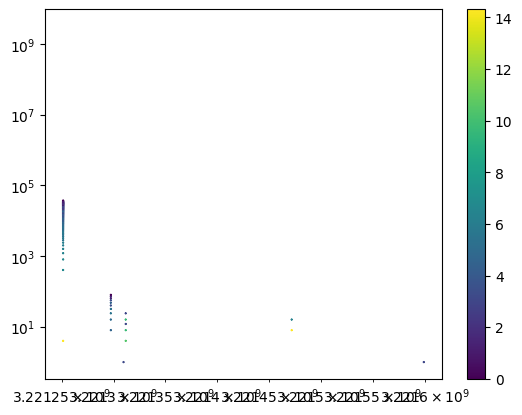

In [11]:
sc = plt.scatter(*zip(*cap_diff_offset.keys()), c=np.log(list(cap_diff_offset.values())), marker='x', s = 0.5)
plt.yscale('log')
plt.xscale('log')
plt.colorbar(sc)

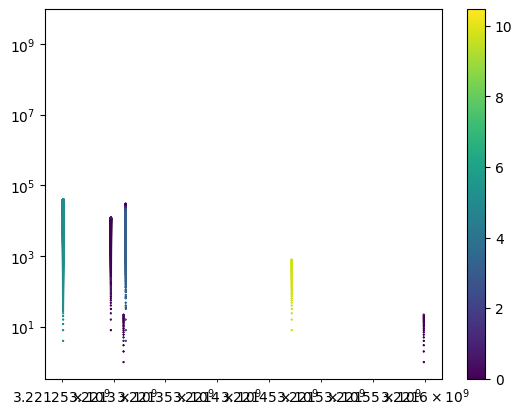

In [12]:
sc = plt.scatter(*zip(*caps_offset.keys()), c=np.log(list(caps_offset.values())), marker='x', s = 0.5)
plt.yscale('log')
plt.xscale('log')
plt.colorbar(sc)

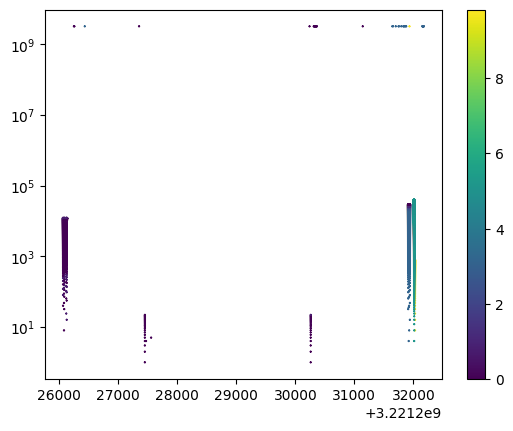

In [13]:
sc = plt.scatter(*zip(*pc_offsets.keys()), c=np.log(list(pc_offsets.values())), marker='x', s = 0.5)
plt.yscale('log')
plt.colorbar(sc)

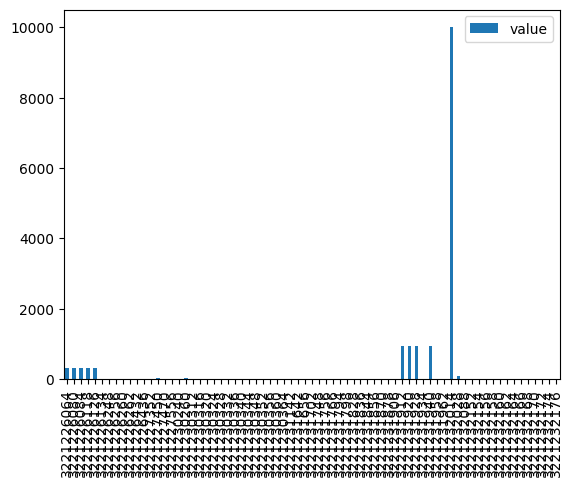

In [14]:
plot_count(count_dict=set_dict_to_count(pc_num_offsets))

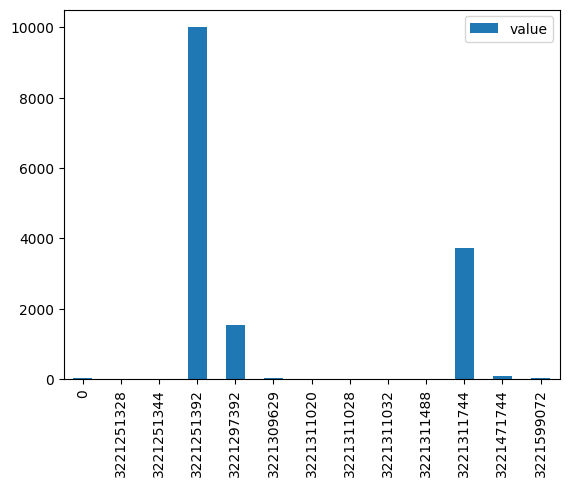

In [15]:
plot_count(count_dict=set_dict_to_count(caps_num_offsets))

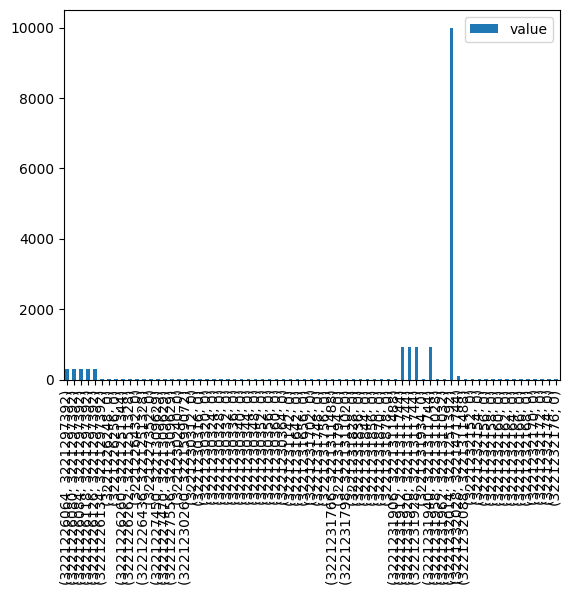

In [16]:
plot_count(count_dict=set_dict_to_count(pc_cap_num_offsets))